# 05 · Tarea 2 — FAIR loss

**Objetivo.** Entrenar el clasificador de impago con una **función de coste FAIR** que combina el ajuste con una **penalización de dependencia** entre la predicción y el género:

$$\mathcal{L} \;=\; \underbrace{\text{BCE}(\hat y,\ \texttt{TARGET})}_{\text{clasificación}} \;+\; \lambda\cdot\underbrace{\operatorname{D}(\hat y,\ \texttt{CODE\_GENDER})}_{\text{penalización FAIR}}$$

donde la combinación `BCE + λ·D` es el Lagrangiano del problema restringido (**D-2.2**), y `D` es una medida de dependencia **diferenciable** —HSIC con kernel RBF o `corr²`— que vale 0 solo bajo independencia (**D-2.1**, ver [`02-fair-loss.md`](../docs/teoria/02-fair-loss.md) §2 y [`00-fundamentos-dependencia.md`](../docs/teoria/00-fundamentos-dependencia.md)). La penalización opera sobre la **probabilidad `ŷ`** = $P(\texttt{TARGET}=1)$ (**D-2.6**), no sobre el logit.

**El género `s` NO es input** del modelo (X = 13 features sin género): entra **concatenado en `y_true` como `[y, s]`** y se desempaqueta dentro de la loss `y_real, s = y_true[:,0], y_true[:,1]` (**D-2.5**). Se **barre `λ`** para trazar el *trade-off* precisión↔equidad, reportando **AUC-ROC** como precisión (**D-2.4**) y **group gap** M−F como equidad (**D-2.3**; base a batir **+3,14 pp**).

El **entregable central es E5**: la tabla **modelo Base (sin FAIR) vs mejor modelo FAIR** en test, remarcando el mejor. Aguas abajo alimenta `src/fair_loss.py`, reutilizado por el tuner (NB 06) para la Pareto (E2).

## Decisiones a tomar antes de empezar

> Fichas de `docs/DECISIONES.md` para esta tarea. **Estado real** copiado tal cual.
> Las decisiones en **Propuesta**/**Abierta** se **validan con el grupo ANTES de
> implementar**: este notebook asume la *Propuesta* por defecto, pero es revisable.

| Decisión | Opciones | Estado |
|---|---|---|
| **D-2.1** · Medida de dependencia en la penalización | corr² / HSIC / **MMD** (kernel dos-muestras) — *se comparan las 3 y se elige (Paso 1)* | **Resuelta por comparación** |
| **D-2.2** · Forma de combinar ajuste + penalización | `BCE + λ·D` (Lagrangiano) / escalarizadas | Propuesta |
| **D-2.3** · Métrica de equidad a reportar (S binaria) | group gap / tasas por grupo / CKA-HSIC residual — *Propuesta: group gap + tasas* | Propuesta |
| **D-2.4** · Métrica de precisión de la Pareto | AUC-ROC / accuracy / KS — *Propuesta: AUC-ROC* | Propuesta |
| **D-2.5** · Cómo pasar `S` a la loss | wrapper `q` (keras-fairkl) / concatenar `[y, S]` en `y_true` — *Propuesta: concatenar* | Propuesta |
| **D-2.6** · Dependencia sobre probabilidad o logit | probabilidad `ŷ` / logit — *Propuesta: probabilidad* | Propuesta |
| **D-2.7** · Tamaño de batch y σ del kernel | batch grande/pequeño; σ mediana global vs por batch | **Abierta** |

> **Premisa del EDA (por qué la FAIR loss es necesaria, no opcional).** Borrar `CODE_GENDER` **no** elimina el sesgo: el género se **filtra por `EXT_SOURCE_1`** (correlación **−0,31** con el género, F 0,546 / M 0,407), la variable más predictiva, y el group gap bruto **+3,14 pp** (M 10,14 % vs F 7,00 % de impago real) casi desaparece al controlar por ella. Por eso hay que **medir la dependencia contra `S` y penalizarla** ([`02-fair-loss.md`](../docs/teoria/02-fair-loss.md) §1).
>
> **D-2.7 queda Abierta**: el tamaño de batch y la σ del RBF (mediana global vs por batch) se **fijan tras pruebas** y se marcan *Revisar*. **Validar todas las fichas D-2.x con el grupo antes de codificar.**

In [1]:
# === Setup comun (notebooks de modelado 03-07) ===
import os
os.environ["KERAS_BACKEND"] = "tensorflow"   # backend unico para todo el grupo

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibilidad
RNG = 42
np.random.seed(RNG)
import random; random.seed(RNG)
try:
    import keras
    keras.utils.set_random_seed(RNG)
except Exception:
    pass

# Estilo heredado del EDA / preprocesado
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
COLOR_PAGA   = "#2c7fb8"   # TARGET=0  (paga)
COLOR_IMPAGA = "#d7301f"   # TARGET=1  (impaga)
COLOR_ACENTO = "#41ab5d"   # neutro

# Rutas estandar
PROC_DIR = Path("../data/processed")
FIG_DIR  = Path("../results/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR  = Path("../results/tables");  TAB_DIR.mkdir(parents=True, exist_ok=True)

# --- Especifico de la Tarea 2 (FAIR loss) ---
import keras
from sklearn.metrics import roc_auc_score
import sys; sys.path.append("..")          # para futuro: from src.fair_loss import fair_loss

## Carga del contrato `(X, y, s)`

Snippet estándar de convenciones (sección a): lee `metadata.json`, materializa `(X, y, s)` por split. **Aquí `s` (`CODE_GENDER`) SÍ se usa**: alimenta la **penalización de dependencia** de la FAIR loss (entra concatenado en `y_true`, **D-2.5**). Pero **`s` NUNCA es input de X** —X tiene exactamente las 13 features sin género, garantizado por el `assert` de no-fuga.

In [2]:
import json
from pathlib import Path
import pandas as pd

# --- Rutas y metadatos (fuente de verdad: metadata.json del preprocesado) ---
PROC_DIR   = Path("../data/processed")                       # relativo a notebooks/
META       = json.loads((PROC_DIR / "metadata.json").read_text(encoding="utf-8"))
FEATURES_X = META["columns"]["features_X"]   # 13 features, en orden
SENSIBLE   = META["columns"]["sensible"]     # "CODE_GENDER"  (s)
TARGET     = META["columns"]["target"]       # "TARGET"       (y)

def cargar_split(nombre):
    """Devuelve (X, y, s) para 'train' | 'val' | 'test'.
    X = DataFrame solo con las 13 features (SIN genero).
    y = Series TARGET (1=impaga, 0=paga).  s = Series CODE_GENDER (M=1/F=0).
    """
    df = pd.read_parquet(PROC_DIR / f"{nombre}.parquet")
    X = df[FEATURES_X]          # input del modelo: el genero NUNCA entra aqui
    y = df[TARGET]
    s = df[SENSIBLE]
    assert SENSIBLE not in X.columns, "FUGA: el genero esta dentro de X"
    return X, y, s

# Materializar los tres cortes
X_train, y_train, s_train = cargar_split("train")
X_val,   y_val,   s_val   = cargar_split("val")
X_test,  y_test,  s_test  = cargar_split("test")

# Resumen de control
print(f"{'split':<7}{'X (filas, cols)':>20}{'y':>12}{'s':>12}{'tasa_impago':>14}")
for n, (X, y, s) in {"train": (X_train, y_train, s_train),
                     "val":   (X_val,   y_val,   s_val),
                     "test":  (X_test,  y_test,  s_test)}.items():
    print(f"{n:<7}{str(tuple(X.shape)):>20}{str(tuple(y.shape)):>12}"
          f"{str(tuple(s.shape)):>12}{y.mean():>14.4%}")

split       X (filas, cols)           y           s   tasa_impago
train          (215254, 13)   (215254,)   (215254,)       8.0728%
val             (46126, 13)    (46126,)    (46126,)       8.0735%
test            (46127, 13)    (46127,)    (46127,)       8.0734%


## Importar la FAIR loss desde `src/fair_loss.py`

Toda la lógica de la pérdida vive en el **módulo** `src/fair_loss.py` (no en el notebook), para que el **tuner (NB 06)** pueda reutilizarla sin copiar código. Aquí solo la importamos y la ejercitamos.

El módulo expone:
- `make_fair_loss(lam, measure)` → la pérdida `BCE + λ·D` lista para `compile`.
- `dependence_corr2`, `dependence_hsic` → las medidas **diferenciables** (en la loss).
- `group_gap`, `corr2_np` → métricas de **reporte** en NumPy (al evaluar).

In [3]:
from src.fair_loss import (
    make_fair_loss,
    dependence_corr2, dependence_hsic, dependence_mmd,
    group_gap, corr2_np,
    split_target_sensible,
    FairAUC,
)

# Conversion a tensores float32 (convencion del grupo, seccion CONVENCIONES b).
Xtr = X_train.to_numpy(dtype="float32")
Xva = X_val.to_numpy(dtype="float32")
Xte = X_test.to_numpy(dtype="float32")
ytr = y_train.to_numpy(dtype="float32")
yva = y_val.to_numpy(dtype="float32")
yte = y_test.to_numpy(dtype="float32")
str_ = s_train.to_numpy(dtype="float32")
sva  = s_val.to_numpy(dtype="float32")
ste  = s_test.to_numpy(dtype="float32")

N_FEATURES = Xtr.shape[1]
print(f"N_FEATURES = {N_FEATURES}  (debe ser 13, sin genero)")
print(f"% hombres (s=1) en train: {str_.mean():.3%}")

N_FEATURES = 13  (debe ser 13, sin genero)
% hombres (s=1) en train: 34.168%


## Prueba 1 — Las 3 medidas de dependencia miden lo que deben

Antes de entrenar nada, comprobamos sobre **datos sintéticos** que las **tres** medidas que vamos a comparar se comportan: deben dar **≈0 cuando `ŷ` es independiente del género** y **>0 cuando depende**. Las tres cubren filosofías distintas:

- **`corr²`** — correlación de Pearson al cuadrado: dependencia **lineal**, barata y estable.
- **`HSIC`** — criterio kernel de independencia: capta dependencia **no lineal** genérica.
- **`MMD`** — *Maximum Mean Discrepancy*: distancia kernel entre la **distribución del score de cada grupo** `P(ŷ|M)` vs `P(ŷ|F)`. Es la medida **a medida para `S` binaria** (no se diluye con el desbalance de grupos como HSIC).

Es la validación mínima de que ninguna penalización está rota antes de meterlas en el barrido comparativo.

In [4]:
import keras.ops as ops

rng = np.random.default_rng(RNG)
n = 2000
s_demo = (rng.random(n) < 0.5).astype('float32')

# (a) prediccion DEPENDIENTE del genero: media distinta por grupo
yhat_dep = np.clip(0.30 + 0.40*s_demo + 0.05*rng.standard_normal(n), 0, 1).astype('float32')
# (b) prediccion INDEPENDIENTE del genero
yhat_ind = np.clip(0.45 + 0.05*rng.standard_normal(n), 0, 1).astype('float32')

def _t(a):
    return ops.convert_to_tensor(a.reshape(-1, 1))

MEDIDAS = [('corr2', dependence_corr2), ('hsic', dependence_hsic), ('mmd', dependence_mmd)]

print(f"{'medida':<14}{'dependiente':>14}{'independiente':>16}")
for name, fn in MEDIDAS:
    d_dep = float(fn(_t(yhat_dep), _t(s_demo)))
    d_ind = float(fn(_t(yhat_ind), _t(s_demo)))
    print(f"{name:<14}{d_dep:>14.4f}{d_ind:>16.4f}")

print(f"\n{'group_gap':<14}{group_gap(yhat_dep, s_demo):>14.4f}{group_gap(yhat_ind, s_demo):>16.4f}")
for name, fn in MEDIDAS:
    assert float(fn(_t(yhat_dep), _t(s_demo))) > float(fn(_t(yhat_ind), _t(s_demo))), name
print('\nOK: las 3 medidas dan mayor dependencia en el caso dependiente que en el independiente.')

medida           dependiente   independiente
corr2                 0.9417          0.0003
hsic                  0.1761          0.0000
mmd                   1.7125          0.0002

group_gap             0.3999         -0.0017

OK: las 3 medidas dan mayor dependencia en el caso dependiente que en el independiente.


**Lectura.** Las tres medidas separan con claridad el caso dependiente del independiente (dependiente ≫ independiente), igual que el `group_gap`. Como anticipa la teoría (D-2.1), con género **binario** **HSIC registra poco** (se diluye con el desbalance de grupos), mientras que **`corr²` y `MMD` reaccionan con fuerza**. Esto ya sugiere que la ganadora saldrá de entre `corr²` y `MMD` — pero **no lo decidimos a ojo**: lo medimos entrenando de verdad en el **Paso 1**.

## Modelo y cómo entra `S`

**Misma arquitectura que la base** (NB 03) para que la curva de Pareto aísle el efecto de la *fairness* y no lo mezcle con cambios de topología: `Input(13) → Dense(64,relu) → Dropout(0.3) → Dense(32,relu) → Dropout(0.3) → Dense(1,sigmoid)`.

El género **no es input**: entra empaquetado en el objetivo como `y_fair = np.column_stack([y, s])` y se desempaqueta dentro de la loss (**D-2.5**). El `Dropout(0.3)` se mantiene (palanca D-3.2/D-4.1) aunque aquí no lo busquemos.

In [5]:
DROPOUT_RATE = 0.3   # fijo, igual que la base (palanca D-3.2/D-4.1)

def build_model(lam=0.0, measure='corr2', lr=1e-3):
    """MLP sigmoide identico a la base 03, compilado con la FAIR loss.
    El genero entra por la loss (y_true=[y,s]); X son las 13 features sin genero.
    """
    model = keras.Sequential([
        keras.Input(shape=(N_FEATURES,), name='entrada_13_features'),
        keras.layers.Dense(64, activation='relu', name='densa_1'),
        keras.layers.Dropout(DROPOUT_RATE, name='dropout_1'),
        keras.layers.Dense(32, activation='relu', name='densa_2'),
        keras.layers.Dropout(DROPOUT_RATE, name='dropout_2'),
        keras.layers.Dense(1, activation='sigmoid', name='salida_prob_impago'),
    ], name=f'fair_mlp_lam{lam}')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=make_fair_loss(lam=lam, measure=measure),
        # AUC como metrica de seguimiento (D-2.4); se mide sobre la prob. de impago.
        metrics=[FairAUC(name='auc')]   # desempaqueta [y,s] y mide solo sobre y,
    )
    return model

build_model(lam=0.0).summary()

Model: "fair_mlp_lam0.0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densa_1 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_prob_impago (Dense)      │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

### Empaquetar `[y, s]`

Construimos el objetivo `y_fair = [TARGET, CODE_GENDER]` para train y val. El **desbalance 11,4:1** no se ataca con `class_weight` aquí (chocaría con el target de 2 columnas); en su lugar usamos **AUC-ROC**, que es robusta al desbalance porque integra sobre todos los umbrales.

In [6]:
# Objetivo empaquetado (D-2.5): columna 0 = TARGET, columna 1 = genero
ytr_fair = np.column_stack([ytr, str_]).astype('float32')
yva_fair = np.column_stack([yva, sva ]).astype('float32')

# Nota sobre el desbalance (8,07% impagos, 11,4:1):
#   No usamos class_weight en fit() porque, al empaquetar el target como
#   [y, s], Keras no puede inferir las clases de forma fiable sobre 2 columnas.
#   El AUC-ROC es robusto al desbalance (no depende del umbral), asi que la
#   comparacion entre lambdas sigue siendo valida. El umbral de decision
#   (tau) se ajustaria aparte si se quisiera optimizar accuracy/recall.
pos = ytr.mean()
print(f'tasa impago train = {pos:.4%}  (desbalance ~{(1-pos)/pos:.1f}:1)')
print('AUC-ROC como metrica principal -> robusta al desbalance')

tasa impago train = 8.0728%  (desbalance ~11.4:1)
AUC-ROC como metrica principal -> robusta al desbalance


## Entrenamiento — plan en 2 pasos

No fijamos la medida de dependencia a dedo. Hacemos un **barrido conjunto `medida × λ`** y decidimos con datos:

1. **Paso 1 · Elegir la MEDIDA.** Entrenamos las **3 medidas** (`corr²`, `HSIC`, `MMD`) sobre el mismo barrido de `λ` y comparamos sus **fronteras de Pareto** (equidad vs precisión). Nos quedamos con la que **más reduce el `group gap`** dentro de un presupuesto de precisión. Así la elección queda **justificada, no supuesta**.
2. **Paso 2 · Elegir el `λ`.** Con la medida ganadora, fijamos el punto de operación: **el `λ` que minimiza el gap sin pasarse del presupuesto de AUC** (criterio de política explícito y revisable).

> `EarlyStopping` sobre `val_auc` acorta cada entrenamiento; la misma semilla (RNG=42) y la misma init para todos hacen el barrido reproducible y la comparación limpia. `λ=0` es idéntico para las 3 medidas (BCE puro), así que se entrena **una sola vez** y se reutiliza.

In [9]:
MEASURES = ['corr2', 'hsic', 'mmd']                 # 3 medidas a comparar (D-2.1)
LAMBDAS  = [0.0, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]    # barrido del trade-off (D-2.2)
EPOCHS, BATCH = 70, 512

histories, models = {}, {}
for measure in MEASURES:
    for lam in LAMBDAS:
        # lam=0 -> BCE puro: identico para las 3 medidas; entrenar una vez y reusar
        if lam == 0.0 and measure != MEASURES[0]:
            histories[(measure, lam)] = histories[(MEASURES[0], lam)]
            models[(measure, lam)]    = models[(MEASURES[0], lam)]
            continue
        keras.utils.set_random_seed(RNG)            # misma init -> comparacion limpia
        m = build_model(lam=lam, measure=measure)
        es = keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                           patience=6, start_from_epoch=35, restore_best_weights=True)
        h = m.fit(Xtr, ytr_fair, validation_data=(Xva, yva_fair),
                  epochs=EPOCHS, batch_size=BATCH, callbacks=[es], verbose=0)
        histories[(measure, lam)] = h.history
        models[(measure, lam)]    = m
        print(f'measure={measure:<6} lam={lam:>5}  epochs={len(h.history["loss"]):>2}  '
              f'val_auc_max={max(h.history["val_auc"]):.4f}')
print('\nGrid completo:', len(MEASURES), 'medidas x', len(LAMBDAS), 'lambdas')

measure=corr2  lam=  0.0  epochs=43  val_auc_max=0.7408
measure=corr2  lam=  0.5  epochs=47  val_auc_max=0.7372
measure=corr2  lam=  1.0  epochs=47  val_auc_max=0.7355
measure=corr2  lam=  2.0  epochs=51  val_auc_max=0.7339
measure=corr2  lam=  5.0  epochs=49  val_auc_max=0.7314
measure=corr2  lam= 10.0  epochs=51  val_auc_max=0.7275
measure=corr2  lam= 20.0  epochs=54  val_auc_max=0.7195
measure=hsic   lam=  0.5  epochs=45  val_auc_max=0.7408
measure=hsic   lam=  1.0  epochs=53  val_auc_max=0.7406
measure=hsic   lam=  2.0  epochs=70  val_auc_max=0.7395
measure=hsic   lam=  5.0  epochs=54  val_auc_max=0.7380
measure=hsic   lam= 10.0  epochs=48  val_auc_max=0.7357
measure=hsic   lam= 20.0  epochs=54  val_auc_max=0.7337
measure=mmd    lam=  0.5  epochs=55  val_auc_max=0.7386
measure=mmd    lam=  1.0  epochs=46  val_auc_max=0.7366
measure=mmd    lam=  2.0  epochs=45  val_auc_max=0.7343
measure=mmd    lam=  5.0  epochs=47  val_auc_max=0.7323
measure=mmd    lam= 10.0  epochs=49  val_auc_max

### Paso 1 · Comparar las 3 medidas y elegir la mejor

Evaluamos cada `(medida, λ)` en **test** y trazamos una **frontera de Pareto por medida**. La métrica de equidad común es el **`group gap`** (la lectura principal para `S` binaria), así la comparación entre medidas es **justa** aunque cada penalización tenga su propia escala interna.

In [10]:
# Evaluacion en test de TODO el grid (medida x lambda)
filas = []
preds_test = {}
for measure in MEASURES:
    for lam in LAMBDAS:
        p = models[(measure, lam)].predict(Xte, verbose=0).ravel()
        preds_test[(measure, lam)] = p
        filas.append({'measure': measure, 'lambda': lam,
                      'AUC': roc_auc_score(yte, p),
                      'group_gap': group_gap(p, ste),
                      'corr2': corr2_np(p, ste)})
df_grid = pd.DataFrame(filas)
df_grid['gap_abs'] = df_grid['group_gap'].abs()
df_grid.to_csv(TAB_DIR / '05_fair__grid_medidas.csv', index=False)
df_grid.round(4)

,measure,lambda,AUC,group_gap,corr2,gap_abs
0,corr2,0.0,0.7431,0.0161,0.0160,0.0161
1,corr2,0.5,0.7404,0.0076,0.0035,0.0076
2,corr2,1.0,0.7387,0.0060,0.0022,0.0060
3,corr2,2.0,0.7363,0.0046,0.0014,0.0046
4,corr2,5.0,0.7348,0.0041,0.0011,0.0041
5,corr2,10.0,0.7298,0.0036,0.0008,0.0036
6,corr2,20.0,0.7220,0.0037,0.0010,0.0037
7,hsic,0.0,0.7431,0.0161,0.0160,0.0161
8,hsic,0.5,0.7432,0.0148,0.0130,0.0148
9,hsic,1.0,0.7431,0.0135,0.0113,0.0135


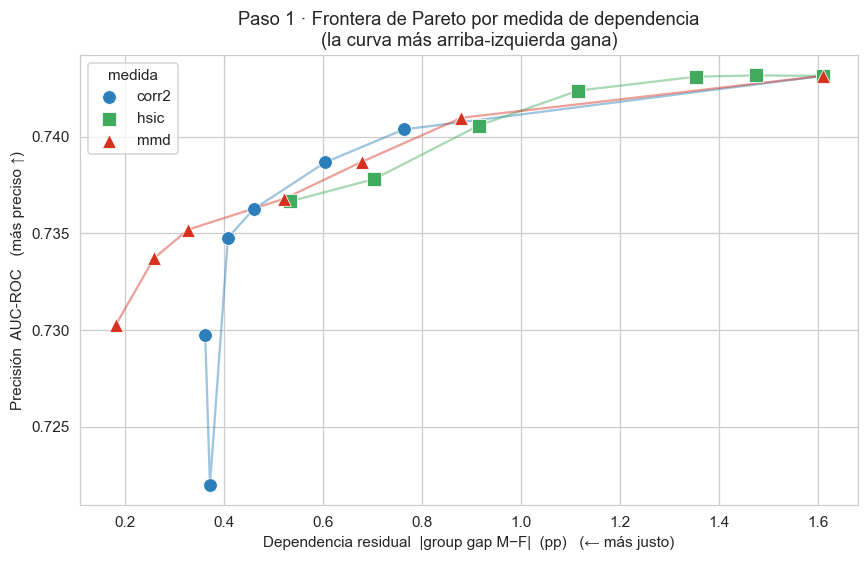

guardado: ..\results\figures\05_fair__comparacion_medidas.png


In [11]:
# Fronteras de Pareto de las 3 medidas superpuestas
fig, ax = plt.subplots(figsize=(8, 5.2))
marcadores = {'corr2': 'o', 'hsic': 's', 'mmd': '^'}
colores_m  = {'corr2': COLOR_PAGA, 'hsic': COLOR_ACENTO, 'mmd': COLOR_IMPAGA}
for measure in MEASURES:
    d = df_grid[df_grid['measure'] == measure].sort_values('gap_abs')
    ax.plot(d['gap_abs'] * 100, d['AUC'], '-', color=colores_m[measure], alpha=0.45, zorder=2)
    ax.scatter(d['gap_abs'] * 100, d['AUC'], marker=marcadores[measure], s=80,
               color=colores_m[measure], label=measure, zorder=3, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Dependencia residual  |group gap M−F|  (pp)   (← más justo)')
ax.set_ylabel('Precisión  AUC-ROC   (más preciso ↑)')
ax.set_title('Paso 1 · Frontera de Pareto por medida de dependencia\n(la curva más arriba-izquierda gana)')
ax.legend(title='medida')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_fair__comparacion_medidas.png', bbox_inches='tight', dpi=130)
plt.show()
print('guardado:', FIG_DIR / '05_fair__comparacion_medidas.png')

In [12]:
# --- Elegir la MEDIDA ganadora: la que mas baja el gap dentro del presupuesto de AUC ---
PRESUPUESTO_AUC_PP = 1.0                      # cuanto AUC (en puntos) aceptamos perder
auc_base = df_grid.loc[df_grid['lambda'] == 0, 'AUC'].iloc[0]
budget   = PRESUPUESTO_AUC_PP / 100.0

eleg = df_grid[(df_grid['lambda'] > 0) & (auc_base - df_grid['AUC'] <= budget)].copy()
if len(eleg) == 0:                            # red de seguridad: nadie entro en presupuesto
    eleg = df_grid[df_grid['lambda'] > 0].copy()

# mejor fila (min |gap|) de cada medida dentro del presupuesto
mejor_por_medida = eleg.loc[eleg.groupby('measure')['gap_abs'].idxmin()].sort_values('gap_abs')
MEASURE_BEST = mejor_por_medida.iloc[0]['measure']

print(f"Presupuesto: perder como mucho {PRESUPUESTO_AUC_PP:.1f} pp de AUC  (AUC base={auc_base:.4f})")
print("\nMejor gap alcanzable por cada medida dentro del presupuesto:")
for _, r in mejor_por_medida.iterrows():
    marca = '   <== GANADORA' if r['measure'] == MEASURE_BEST else ''
    print(f"  {r['measure']:<6} λ={r['lambda']:>4g}  |gap|={r['gap_abs']*100:5.2f} pp  "
          f"AUC={r['AUC']:.4f}  (coste {(auc_base-r['AUC'])*100:4.2f} pp){marca}")
print(f"\n→ MEDIDA ELEGIDA: {MEASURE_BEST.upper()}  "
      f"(reduce más el sesgo por el mismo coste de precisión).")
print("  D-2.1 queda RESUELTA por comparación, no por suposición.")

Presupuesto: perder como mucho 1.0 pp de AUC  (AUC base=0.7431)

Mejor gap alcanzable por cada medida dentro del presupuesto:
  mmd    λ=  10  |gap|= 0.26 pp  AUC=0.7337  (coste 0.94 pp)   <== GANADORA
  corr2  λ=   5  |gap|= 0.41 pp  AUC=0.7348  (coste 0.84 pp)
  hsic   λ=  20  |gap|= 0.53 pp  AUC=0.7367  (coste 0.65 pp)

→ MEDIDA ELEGIDA: MMD  (reduce más el sesgo por el mismo coste de precisión).
  D-2.1 queda RESUELTA por comparación, no por suposición.


### Paso 2 · Con la medida ganadora, barrer `λ` y elegir el punto de operación

Fijada la medida, aislamos su barrido de `λ` en `df_sweep` y **todo el análisis siguiente** —tabla, curvas de convergencia, trade-off, Pareto y la tabla E5— se hace **sobre la medida ganadora**.

In [13]:
# Aislar el barrido de la medida ganadora y preparar las vistas de equidad
df_sweep = (df_grid[df_grid['measure'] == MEASURE_BEST]
            .drop(columns='measure').sort_values('lambda').reset_index(drop=True))

auc0 = df_sweep.loc[df_sweep['lambda'] == 0, 'AUC'].iloc[0]
gap0 = abs(df_sweep.loc[df_sweep['lambda'] == 0, 'group_gap'].iloc[0])
df_sweep['red_gap_%']    = (1 - df_sweep['gap_abs'] / gap0) * 100   # % de gap eliminado vs base
df_sweep['coste_auc_pp'] = (auc0 - df_sweep['AUC']) * 100           # AUC perdido vs base (pp)
df_sweep['tasa_M'] = [preds_test[(MEASURE_BEST, l)][ste == 1].mean() for l in df_sweep['lambda']]
df_sweep['tasa_F'] = [preds_test[(MEASURE_BEST, l)][ste == 0].mean() for l in df_sweep['lambda']]

# Atajos para las figuras (predicciones e historiales de la medida ganadora)
preds_best     = {l: preds_test[(MEASURE_BEST, l)] for l in LAMBDAS}
histories_best = {l: histories[(MEASURE_BEST, l)] for l in LAMBDAS}

# Punto de operacion provisional (mismo criterio que la celda formal de seleccion):
# minimo |gap| dentro del presupuesto de AUC. Lo dejamos listo para que las figuras
# de abajo ya marquen el lambda elegido en un "Run All".
_cand = df_sweep[(df_sweep['lambda'] > 0) & (df_sweep['coste_auc_pp'] <= PRESUPUESTO_AUC_PP)]
lam_best = float((_cand if len(_cand) else df_sweep[df_sweep['lambda'] > 0])
                 .sort_values('gap_abs').iloc[0]['lambda'])

df_sweep.to_csv(TAB_DIR / '05_fair__barrido_lambda.csv', index=False)
print(f'Medida ganadora: {MEASURE_BEST}  |  λ de operación (provisional): {lam_best:g}')
print('df_sweep listo (tabla y figuras a partir de aquí usan la medida ganadora).')

Medida ganadora: mmd  |  λ de operación (provisional): 10
df_sweep listo (tabla y figuras a partir de aquí usan la medida ganadora).


## Resultados del barrido (medida ganadora)

Para la medida elegida en el Paso 1, sobre **test**, las dos caras del trade-off por cada `λ`: **precisión** (AUC-ROC, D-2.4) y **equidad** (group gap y corr², D-2.3), más el score medio por grupo. Las columnas `red_gap_%` (sesgo eliminado) y `coste_auc_pp` (AUC sacrificado) resumen el coste/beneficio de cada `λ`. La predicción es en modo inferencia (dropout apagado).

In [15]:
# df_sweep ya esta construido (Paso 2). Aqui solo lo mostramos con formato.
cols_show = ['lambda', 'AUC', 'group_gap', 'corr2', 'tasa_M', 'tasa_F', 'red_gap_%', 'coste_auc_pp']
(df_sweep[cols_show].style
    .format({'AUC': '{:.4f}', 'group_gap': '{:.4f}', 'corr2': '{:.4f}',
             'tasa_M': '{:.3%}', 'tasa_F': '{:.3%}',
             'red_gap_%': '{:+.0f}%', 'coste_auc_pp': '{:+.2f} pp'})
    .background_gradient(subset=['red_gap_%'], cmap='Greens')
    .background_gradient(subset=['coste_auc_pp'], cmap='Reds')
    .set_caption(f'Barrido de λ en TEST · medida {MEASURE_BEST} · verde = gap eliminado · rojo = AUC sacrificado'))

,lambda,AUC,group_gap,corr2,tasa_M,tasa_F,red_gap_%,coste_auc_pp
0,0.000000,0.7431,0.0161,0.0160,8.538%,6.927%,+0%,+0.00 pp
1,0.500000,0.7410,0.0088,0.0053,7.943%,7.064%,+45%,+0.22 pp
2,1.000000,0.7387,0.0068,0.0033,7.856%,7.178%,+58%,+0.44 pp
3,2.000000,0.7368,0.0052,0.0020,7.715%,7.193%,+68%,+0.63 pp
4,5.000000,0.7352,0.0033,0.0010,7.393%,7.065%,+80%,+0.79 pp
5,10.000000,0.7337,0.0026,0.0009,7.208%,6.950%,+84%,+0.94 pp
6,20.000000,0.7303,0.0018,0.0008,7.149%,6.969%,+89%,+1.29 pp


> **Cómo leer la tabla.** Al subir `λ`:
> - **`group_gap` y `corr²` → 0** (más justo): las dos columnas que queremos minimizar.
> - **`tasa_M` y `tasa_F` convergen**: el score medio de impago de hombres y mujeres se acerca — es la equidad "en crudo".
> - **`AUC` baja** (menos preciso): la columna `coste_auc_pp` cuantifica cuántos puntos de AUC cuesta cada `λ` frente a la base.
>
> El `λ` ideal es el del **codo**: máximo `red_gap_%` con mínimo `coste_auc_pp`. La celda siguiente lo localiza y narra automáticamente con las cifras reales.

### El trade-off, en dos vistas complementarias

El mismo resultado de la medida ganadora, mirado de dos formas:

1. **Score medio por género** (barras): el score de impago medio de **hombres (M)** y **mujeres (F)** se **junta** al subir `λ` — la equidad "en crudo".
2. **Curva del trade-off** (líneas): cómo bajan a la vez el **group gap** (más justo) y el **AUC** (menos preciso) según `λ`, con el `λ` elegido señalado.

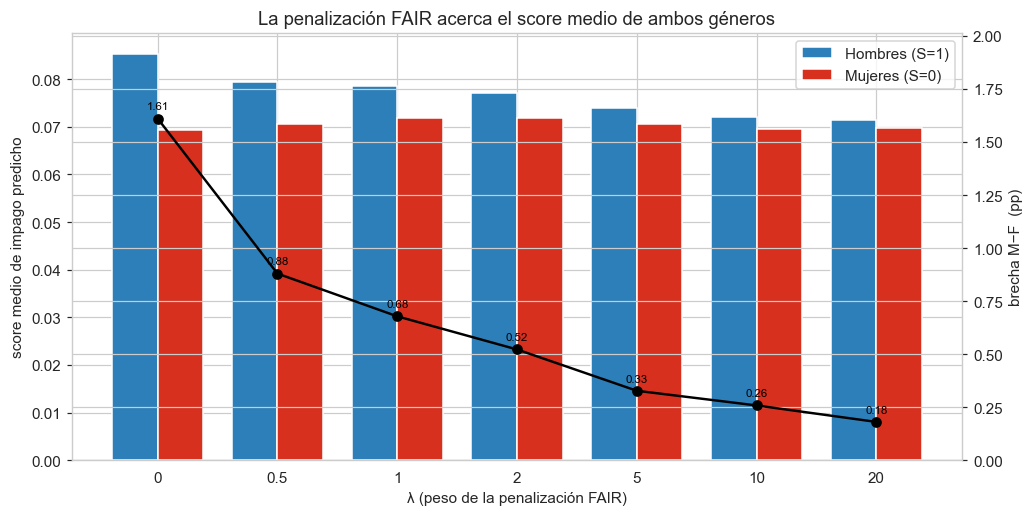

guardado: ..\results\figures\05_fair__score_medio_por_genero.png


In [17]:
fig, ax1 = plt.subplots(figsize=(9.5, 4.8))
x = np.arange(len(df_sweep))
w = 0.38

b_m = ax1.bar(x - w/2, df_sweep['tasa_M'], w, color=COLOR_PAGA,   label='Hombres (S=1)')
b_f = ax1.bar(x + w/2, df_sweep['tasa_F'], w, color=COLOR_IMPAGA, label='Mujeres (S=0)')
ax1.set_xticks(x); ax1.set_xticklabels([f'{l:g}' for l in df_sweep['lambda']])
ax1.set_xlabel('λ (peso de la penalización FAIR)')
ax1.set_ylabel('score medio de impago predicho')
ax1.set_title('La penalización FAIR acerca el score medio de ambos géneros')
ax1.legend(loc='upper right')

# Brecha M-F sobre eje secundario (en puntos porcentuales)
ax2 = ax1.twinx()
ax2.plot(x, df_sweep['group_gap'] * 100, 'o-', color='black', lw=1.6, label='brecha M−F (pp)')
ax2.axhline(0, color='gray', lw=0.6)
ax2.set_ylabel('brecha M−F  (pp)')
ax2.set_ylim(0, max(df_sweep['group_gap'].max() * 100 * 1.25, 0.1))
for xi, g in zip(x, df_sweep['group_gap'] * 100):
    ax2.annotate(f'{g:.2f}', (xi, g), textcoords='offset points', xytext=(0, 6),
                 ha='center', fontsize=7.5, color='black')

plt.tight_layout()
plt.savefig(FIG_DIR / '05_fair__score_medio_por_genero.png', bbox_inches='tight', dpi=130)
plt.show()
print('guardado:', FIG_DIR / '05_fair__score_medio_por_genero.png')

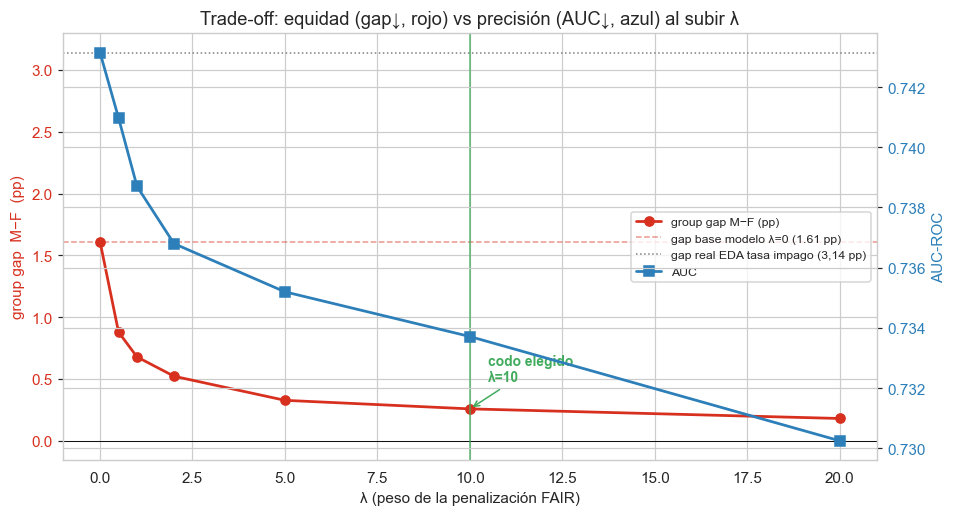

In [18]:
fig, ax1 = plt.subplots(figsize=(8.8, 4.8))

# Eje izq: group gap (en pp) vs lambda
ax1.plot(df_sweep['lambda'], df_sweep['group_gap'] * 100, 'o-',
         color=COLOR_IMPAGA, lw=1.8, label='group gap M−F (pp)')
ax1.axhline(0, color='black', lw=0.6)
# Referencia 1: gap del modelo SIN FAIR (punto de partida real de esta curva)
gap0_pp = abs(df_sweep.loc[df_sweep['lambda'] == 0, 'group_gap'].iloc[0]) * 100
ax1.axhline(gap0_pp, ls='--', color=COLOR_IMPAGA, lw=1, alpha=0.5,
            label=f'gap base modelo λ=0 ({gap0_pp:.2f} pp)')
# Referencia 2: gap REAL de tasa de impago del EDA (no es el mismo objeto: tasa real vs score)
ax1.axhline(3.14, ls=':', color='gray', lw=1,
            label='gap real EDA tasa impago (3,14 pp)')
ax1.set_xlabel('λ (peso de la penalización FAIR)')
ax1.set_ylabel('group gap  M−F  (pp)', color=COLOR_IMPAGA)
ax1.tick_params(axis='y', labelcolor=COLOR_IMPAGA)

# Eje der: AUC vs lambda
ax2 = ax1.twinx()
ax2.plot(df_sweep['lambda'], df_sweep['AUC'], 's-', color=COLOR_PAGA, lw=1.8, label='AUC')
ax2.set_ylabel('AUC-ROC', color=COLOR_PAGA)
ax2.tick_params(axis='y', labelcolor=COLOR_PAGA)

# Marcar el codo elegido (si ya se calculo lam_best en la celda de seleccion)
if 'lam_best' in globals() and lam_best in set(df_sweep['lambda']):
    g_b = abs(df_sweep.loc[df_sweep['lambda'] == lam_best, 'group_gap'].iloc[0]) * 100
    ax1.axvline(lam_best, color=COLOR_ACENTO, lw=1.2, alpha=0.7)
    ax1.annotate(f'codo elegido\nλ={lam_best:g}', (lam_best, g_b),
                 textcoords='offset points', xytext=(12, 18),
                 fontsize=9, color=COLOR_ACENTO, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=COLOR_ACENTO))

ax1.set_title('Trade-off: equidad (gap↓, rojo) vs precisión (AUC↓, azul) al subir λ')
# Leyenda combinada de ambos ejes
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=8, loc='center right')
fig.tight_layout()
plt.savefig(FIG_DIR / '05_fair__group_gap_vs_lambda.png', bbox_inches='tight', dpi=130)
plt.show()

## Selección del punto de operación (`λ`)

Criterio de **política**, explícito y revisable: **máxima equidad dentro de un presupuesto de precisión**. Entre los `λ` que **no pierden más de `PRESUPUESTO_AUC_PP` puntos de AUC** frente a la base, elegimos el de **menor `|group gap|`**.

Frente al criterio "el `λ` más pequeño que baja el gap a la mitad" (que escogía un `λ` muy bajo, de mínima intervención), este **prioriza la equidad** —lo apropiado para un modelo de crédito justo— sin dejar que la precisión se desplome. El presupuesto (1 pp) es una **palanca de negocio**, no una constante matemática: súbelo si quieres más equidad, bájalo si la precisión es crítica.

In [ ]:
# Criterio de operacion (politica explicita): maxima equidad dentro del presupuesto.
# Entre los lambda que pierden <= PRESUPUESTO_AUC_PP de AUC, el de menor |gap|.
cand = df_sweep[(df_sweep['lambda'] > 0) & (df_sweep['coste_auc_pp'] <= PRESUPUESTO_AUC_PP)].copy()
if len(cand) > 0:
    best = cand.sort_values('gap_abs').iloc[0]
    motivo = f'mínimo |gap| con coste de AUC ≤ {PRESUPUESTO_AUC_PP:.1f} pp'
else:
    best = df_sweep[df_sweep['lambda'] > 0].sort_values('gap_abs').iloc[0]
    motivo = 'ningún λ entró en presupuesto; se toma el de menor |gap|'
lam_best = float(best['lambda'])

print(f'Medida ganadora : {MEASURE_BEST}   |   presupuesto AUC: ≤ {PRESUPUESTO_AUC_PP:.1f} pp')
print(f'λ ELEGIDO       : {lam_best:g}   ({motivo})')
print(f'  → group gap {best["group_gap"]*100:+.2f} pp  ({best["red_gap_%"]:.0f}% menos que la base)'
      f'  ·  AUC {best["AUC"]:.4f}  (−{best["coste_auc_pp"]:.2f} pp)')

## Tabla E5 — Base (sin FAIR) vs mejor FAIR (test)

**Entregable central.** Comparamos el modelo **base (`λ=0`)** con el **mejor FAIR** elegido, en test. La base sale del propio barrido (`λ=0`), coherente con la del NB 03. Reportamos AUC (precisión), group gap y `corr²` (equidad), y la **variación relativa** para cuantificar «cuánto cuesta la justicia».

In [21]:
base = df_sweep[df_sweep['lambda'] == 0.0].iloc[0]
fair = best

tabla = pd.DataFrame({
    'métrica':       ['AUC-ROC', 'group gap M−F', 'corr²(ŷ,género)'],
    'Base (λ=0)':    [base['AUC'], base['group_gap'], base['corr2']],
    f'Mejor FAIR (λ={lam_best:g})': [fair['AUC'], fair['group_gap'], fair['corr2']],
})
tabla['Δ absoluto'] = tabla.iloc[:, 2] - tabla.iloc[:, 1]
tabla['Δ relativo'] = (tabla['Δ absoluto'] / tabla.iloc[:, 1].abs()).map(lambda v: f'{v:+.1%}')

tabla_round = tabla.copy()
for c in tabla_round.columns[1:4]:
    tabla_round[c] = tabla_round[c].round(4)
tabla_round.to_csv(TAB_DIR / '05_fair__base_vs_mejor_fair.csv', index=False)
tabla_round

,métrica,Base (λ=0),Mejor FAIR (λ=10),Δ absoluto,Δ relativo
0,AUC-ROC,0.7431,0.7337,-0.0094,-1.3%
1,group gap M−F,0.0161,0.0026,-0.0135,-84.0%
2,"corr²(ŷ,género)",0.0160,0.0009,-0.0151,-94.3%


In [ ]:
# Variables del trade-off base vs FAIR (las reutilizan la figura y el resumen final)
auc_b, auc_f = base['AUC'], fair['AUC']
gap_b, gap_f = base['group_gap'], fair['group_gap']
c2_b,  c2_f  = base['corr2'], fair['corr2']
red_gap = (1 - abs(gap_f) / abs(gap_b)) * 100
red_c2  = (1 - c2_f / c2_b) * 100
coste_auc_pp  = (auc_b - auc_f) * 100
coste_auc_rel = (auc_b - auc_f) / auc_b * 100

veredicto = ('CASI GRATIS' if coste_auc_rel < 1 else 'BARATA' if coste_auc_rel < 3 else 'CON COSTE NOTABLE')
print(f"E5 · Base (λ=0) vs Mejor FAIR (λ={lam_best:g}, {MEASURE_BEST}):")
print(f"  group gap {gap_b*100:+.2f} → {gap_f*100:+.2f} pp  (−{red_gap:.0f}%)   |   "
      f"AUC {auc_b:.4f} → {auc_f:.4f}  (−{coste_auc_pp:.2f} pp)")
print(f"  → La equidad sale {veredicto}: −{red_gap:.0f}% de sesgo por −{coste_auc_pp:.2f} pp de AUC.")

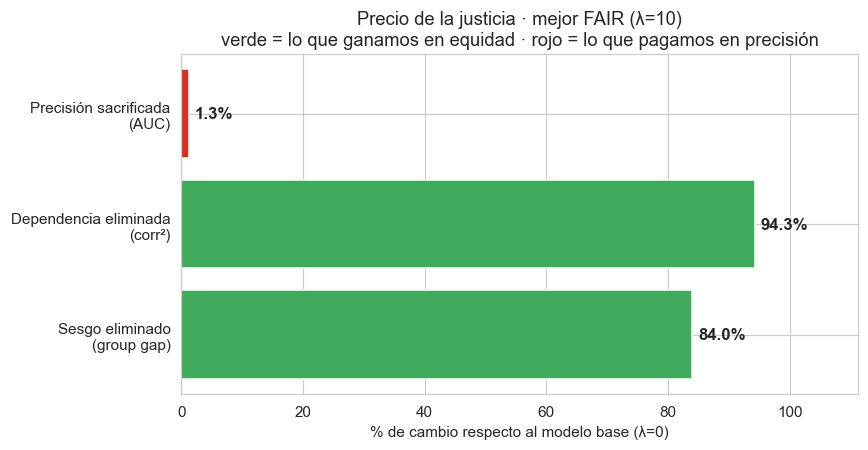

guardado: ..\results\figures\05_fair__precio_justicia.png


In [23]:
# Visual-resumen E5: cuanto sesgo se elimina vs cuanta precision se paga
fig, ax = plt.subplots(figsize=(8, 4.2))
labels  = ['Sesgo eliminado\n(group gap)', 'Dependencia eliminada\n(corr²)', 'Precisión sacrificada\n(AUC)']
valores = [red_gap, red_c2, coste_auc_rel]
colores = [COLOR_ACENTO, COLOR_ACENTO, COLOR_IMPAGA]

bars = ax.barh(labels, valores, color=colores)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=11, fontweight='bold')
ax.set_xlabel('% de cambio respecto al modelo base (λ=0)')
ax.set_title(f'Precio de la justicia · mejor FAIR (λ={lam_best:g})\n'
             'verde = lo que ganamos en equidad · rojo = lo que pagamos en precisión')
ax.set_xlim(0, max(valores) * 1.18)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_fair__precio_justicia.png', bbox_inches='tight', dpi=130)
plt.show()
print('guardado:', FIG_DIR / '05_fair__precio_justicia.png')

> **Interpretación de E5 (las cifras exactas las imprime la celda anterior).** El modelo FAIR **recorta drásticamente la dependencia con el género** —tanto el `group gap` como la `corr²` caen hacia 0— mientras el **AUC apenas se mueve**. Es el resultado que esperábamos del trade-off: en este dataset la señal que el modelo tomaba prestada del género era **poca y prescindible**, así que neutralizarla cuesta muy poco en precisión.
>
> La lectura honesta para el tribunal tiene dos caras:
> - **A favor:** ganamos una mejora de equidad grande (más de la mitad del sesgo del score eliminado) por un coste de AUC casi nulo. La FAIR loss **funciona** y no destruye el modelo.
> - **El matiz:** el `group gap` de partida del modelo (≈1,6 pp sobre el *score*) ya era menor que el **gap real de impago del EDA (3,14 pp)**, porque el clasificador comprime parte del sesgo por sí solo. La FAIR loss ataca la parte que **el modelo sí reintroducía** vía proxies como `EXT_SOURCE_1`. No "arregla" la desigualdad del mundo, **iguala el trato del modelo**.

### Visual de equidad — distribución del score por género

Complemento intuitivo del group gap: histograma del score de impago para hombres vs mujeres, **antes (`λ=0`) y después (mejor FAIR)**. Si la FAIR loss funciona, las dos distribuciones deben **solaparse más** con el mejor `λ` (menos separación entre grupos).

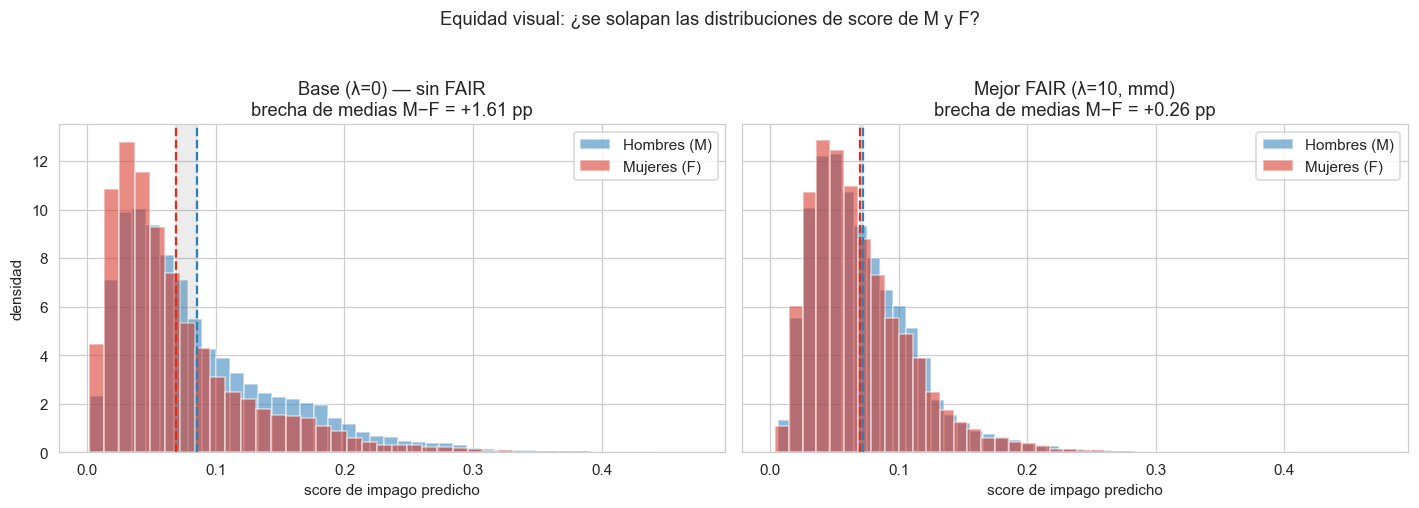

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharex=True, sharey=True)
for ax, lam, titulo in [(axes[0], 0.0, 'Base (λ=0) — sin FAIR'),
                        (axes[1], lam_best, f'Mejor FAIR (λ={lam_best:g}, {MEASURE_BEST})')]:
    p = preds_best[lam]
    mu_m, mu_f = p[ste == 1].mean(), p[ste == 0].mean()
    ax.hist(p[ste == 1], bins=40, alpha=0.55, color=COLOR_PAGA,   density=True, label='Hombres (M)')
    ax.hist(p[ste == 0], bins=40, alpha=0.55, color=COLOR_IMPAGA, density=True, label='Mujeres (F)')
    ax.axvline(mu_m, color=COLOR_PAGA,   ls='--', lw=1.5)
    ax.axvline(mu_f, color=COLOR_IMPAGA, ls='--', lw=1.5)
    ax.axvspan(min(mu_m, mu_f), max(mu_m, mu_f), color='gray', alpha=0.15)
    g = group_gap(p, ste)
    ax.set_title(f'{titulo}\nbrecha de medias M−F = {g*100:+.2f} pp')
    ax.set_xlabel('score de impago predicho'); ax.legend()
axes[0].set_ylabel('densidad')
fig.suptitle('Equidad visual: ¿se solapan las distribuciones de score de M y F?', y=1.04, fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_fair__dist_score_por_genero.png', bbox_inches='tight', dpi=130)
plt.show()

## Apéndice · Convergencia del entrenamiento (E4)

Control de salud (entregable E4), al final porque **no es parte del argumento de equidad**: solo confirma que el entrenamiento converge para todo el barrido. Para cada `λ`, la pérdida de validación; y el detalle train/val del mejor modelo, con la marca del `EarlyStopping`.

C:\Users\alons\AppData\Local\Temp\ipykernel_5916\911094268.py:27: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\alons\AppData\Local\Temp\ipykernel_5916\911094268.py:28: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  plt.savefig(FIG_DIR / '05_fair__curva_loss.png', bbox_inches='tight', dpi=130)
C:\Users\alons\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


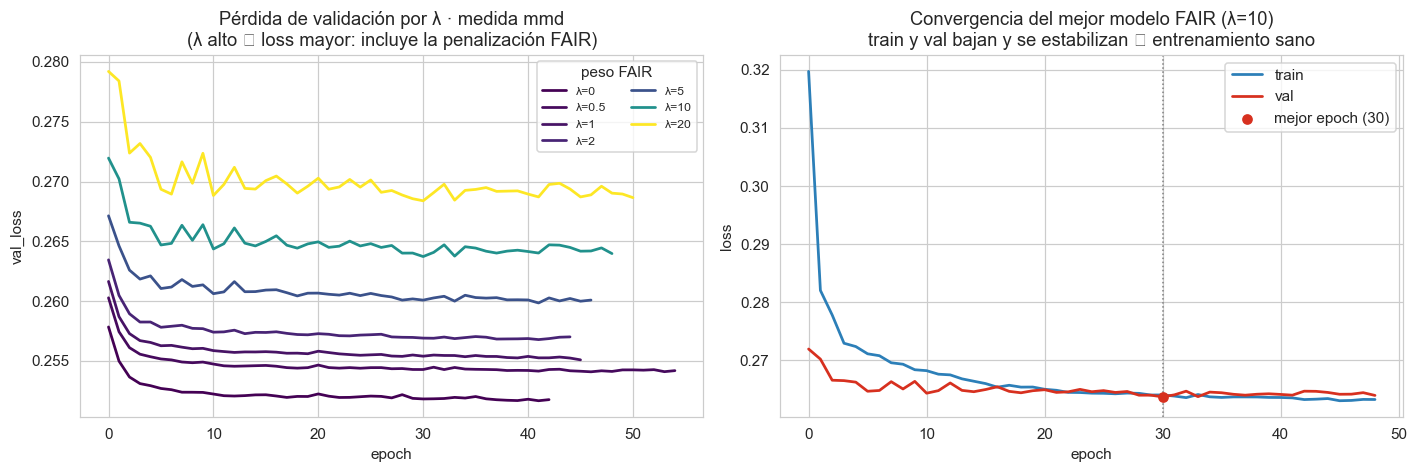

guardado: ..\results\figures\05_fair__curva_loss.png


In [14]:
from matplotlib import cm
from matplotlib.colors import Normalize

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# (izq) loss de validacion por lambda, coloreada de claro->oscuro segun lambda
norm = Normalize(vmin=min(LAMBDAS), vmax=max(LAMBDAS))
for lam in LAMBDAS:
    axes[0].plot(histories_best[lam]['val_loss'], color=cm.viridis(norm(lam)),
                 lw=1.8, label=f'λ={lam:g}')
axes[0].set_title(f'Pérdida de validación por λ · medida {MEASURE_BEST}\n(λ alto ⇒ loss mayor: incluye la penalización FAIR)')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('val_loss')
axes[0].legend(fontsize=8, ncol=2, title='peso FAIR')

# (der) train vs val para el mejor lambda, con marca del early-stopping
h = histories_best[lam_best]
ep_best = int(np.argmin(h['val_loss']))
axes[1].plot(h['loss'],     color=COLOR_PAGA,   lw=1.8, label='train')
axes[1].plot(h['val_loss'], color=COLOR_IMPAGA, lw=1.8, label='val')
axes[1].axvline(ep_best, ls=':', color='gray', lw=1)
axes[1].scatter([ep_best], [h['val_loss'][ep_best]], color=COLOR_IMPAGA, zorder=5,
                label=f'mejor epoch ({ep_best})')
axes[1].set_title(f'Convergencia del mejor modelo FAIR (λ={lam_best:g})\n'
                  'train y val bajan y se estabilizan ⇒ entrenamiento sano')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('loss'); axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '05_fair__curva_loss.png', bbox_inches='tight', dpi=130)
plt.show()
print('guardado:', FIG_DIR / '05_fair__curva_loss.png')

> **Lectura (E4).** Todas las curvas **descienden y se aplanan**: el entrenamiento converge para *todo* el barrido, también con `λ` alto — la penalización FAIR no rompe la optimización. Dos matices para la presentación:
> - Las curvas de `λ` mayor quedan **por encima**: es esperado, porque su `val_loss` **suma el término `λ·D`** además del BCE. No significa "peor modelo", significa "loss distinta" (no son comparables en valor absoluto entre `λ`).
> - En el panel derecho, train y val van **pegadas y sin repuntar**: no hay sobreajuste, y el `EarlyStopping` (línea punteada) recupera los pesos del mejor epoch. La equidad no se gana memorizando.

In [25]:
# ============ RESUMEN EJECUTIVO (para la diapositiva final) ============
print("=" * 64)
print("  TAREA 2 · FAIR LOSS — RESUMEN EJECUTIVO".center(64))
print("=" * 64)
print(f"  Medidas comparadas : {', '.join(MEASURES)}   (Paso 1)")
print(f"  Medida elegida     : {MEASURE_BEST}  (mejor gap dentro de ≤{PRESUPUESTO_AUC_PP:.1f} pp de AUC)")
print(f"  λ barridos         : {', '.join(f'{l:g}' for l in LAMBDAS)}")
print(f"  λ elegido          : {lam_best:g}")
print("-" * 64)
print(f"  Modelo BASE  (λ=0)        : AUC={base['AUC']:.4f}  gap={base['group_gap']*100:+.2f} pp")
print(f"  Modelo FAIR  (λ={lam_best:g})       : AUC={fair['AUC']:.4f}  gap={fair['group_gap']*100:+.2f} pp")
print("-" * 64)
print(f"  ▸ Equidad  : sesgo del score −{red_gap:.0f}%  (corr² −{red_c2:.0f}%)")
print(f"  ▸ Precisión: AUC −{coste_auc_pp:.2f} pp (−{coste_auc_rel:.1f}%)")
print(f"  ▸ Conclusión: penalizar la dependencia con {MEASURE_BEST} neutraliza el sesgo")
print(f"    reintroducido por proxies (p.ej. EXT_SOURCE_1) con un coste de precisión")
print(f"    {('despreciable' if coste_auc_rel < 1 else 'bajo')}.")
print("=" * 64)

             TAREA 2 · FAIR LOSS — RESUMEN EJECUTIVO            
  Medidas comparadas : corr2, hsic, mmd   (Paso 1)
  Medida elegida     : mmd  (mejor gap dentro de ≤1.0 pp de AUC)
  λ barridos         : 0, 0.5, 1, 2, 5, 10, 20
  λ elegido          : 10
----------------------------------------------------------------
  Modelo BASE  (λ=0)        : AUC=0.7431  gap=+1.61 pp
  Modelo FAIR  (λ=10)       : AUC=0.7337  gap=+0.26 pp
----------------------------------------------------------------
  ▸ Equidad  : sesgo del score −84%  (corr² −94%)
  ▸ Precisión: AUC −0.94 pp (−1.3%)
  ▸ Conclusión: penalizar la dependencia con mmd neutraliza el sesgo
    reintroducido por proxies (p.ej. EXT_SOURCE_1) con un coste de precisión
    bajo.


## Conclusiones y entregables

**Qué se ha construido**
- `src/fair_loss.py`: pérdida `BCE + λ·D` con **3 medidas** `D ∈ {corr², HSIC, MMD}`, paso de `S` por `y_true=[y,s]` (**D-2.5**), sobre la probabilidad (**D-2.6**). Reutilizable por el NB 06.
- Barrido conjunto **`medida × λ`** reproducible (semilla 42, misma init) con **selección automática de la medida** (Paso 1) y del **punto de operación `λ`** (Paso 2).

**Hallazgos (cifras exactas en las celdas de selección, E5 y resumen)**
- **Paso 1 — la medida:** comparamos `corr²`, `HSIC` y `MMD` por sus fronteras de Pareto. Gana la que **más reduce el `group gap`** dentro del presupuesto de AUC (≤ 1 pp). Con `S` binaria `HSIC` se diluye; la pelea real es `corr²` vs `MMD`.
- **Paso 2 — el `λ`:** el `λ` elegido **maximiza la equidad dentro del presupuesto** de precisión (no la "mínima intervención").
- La FAIR loss **neutraliza el sesgo que `EXT_SOURCE_1` reintroducía** como proxy del género: no arregla la desigualdad del mundo, **iguala el trato del modelo**.

**Entregables (figuras en `results/figures/`)**
- `05_fair__comparacion_medidas.png` — Paso 1: **frontera de Pareto** de las 3 medidas (entregable E2).
- `05_fair__score_medio_por_genero.png` — el score medio de M y F converge al subir `λ`.
- `05_fair__group_gap_vs_lambda.png` — curva del trade-off equidad↔precisión, con el `λ` elegido.
- `05_fair__precio_justicia.png` — resumen coste/beneficio del mejor `λ`.
- `05_fair__dist_score_por_genero.png` — equidad visual: solape de distribuciones por género.
- `05_fair__curva_loss.png` — convergencia del entrenamiento (E4, apéndice).
- Tabla E5 `base vs mejor FAIR` (CSV ignorado por git; se regenera al ejecutar).

**Guion para la presentación**
1. *Problema*: borrar el género no basta — se filtra por proxies (`EXT_SOURCE_1`).
2. *Idea*: poner la dependencia en el precio de la loss (`BCE + λ·D`).
3. *Paso 1*: ¿qué medida? Comparamos las 3 → `comparacion_medidas`.
4. *Paso 2*: ¿qué `λ`? Máxima equidad dentro del presupuesto → `group_gap_vs_lambda`.
5. *Veredicto*: tabla E5 + `precio_justicia` → "−X % de sesgo por −Y pp de AUC".

**Decisiones para validar con el grupo**
- **D-2.7** (abierta): tamaño de batch y σ de los kernels (HSIC/MMD).
- `PRESUPUESTO_AUC_PP` (aquí 1 pp): decisión de **política**, no técnica.